In [1]:
# Import libraries :

import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
# render figures directly in the notebook :
%matplotlib inline
# render higher resolution images :
%config InlineBackend.figure_format = 'retina'


# Seaborn is a Python data visualization library based on matplotlib :
import seaborn as sns 

In [2]:
penguins = pd.read_csv ('penguins_size.csv')

In [3]:
penguins

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [4]:
penguins.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [5]:
penguins.dtypes

species               object
island                object
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

In [6]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [7]:
penguins.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [8]:
penguins.isna().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

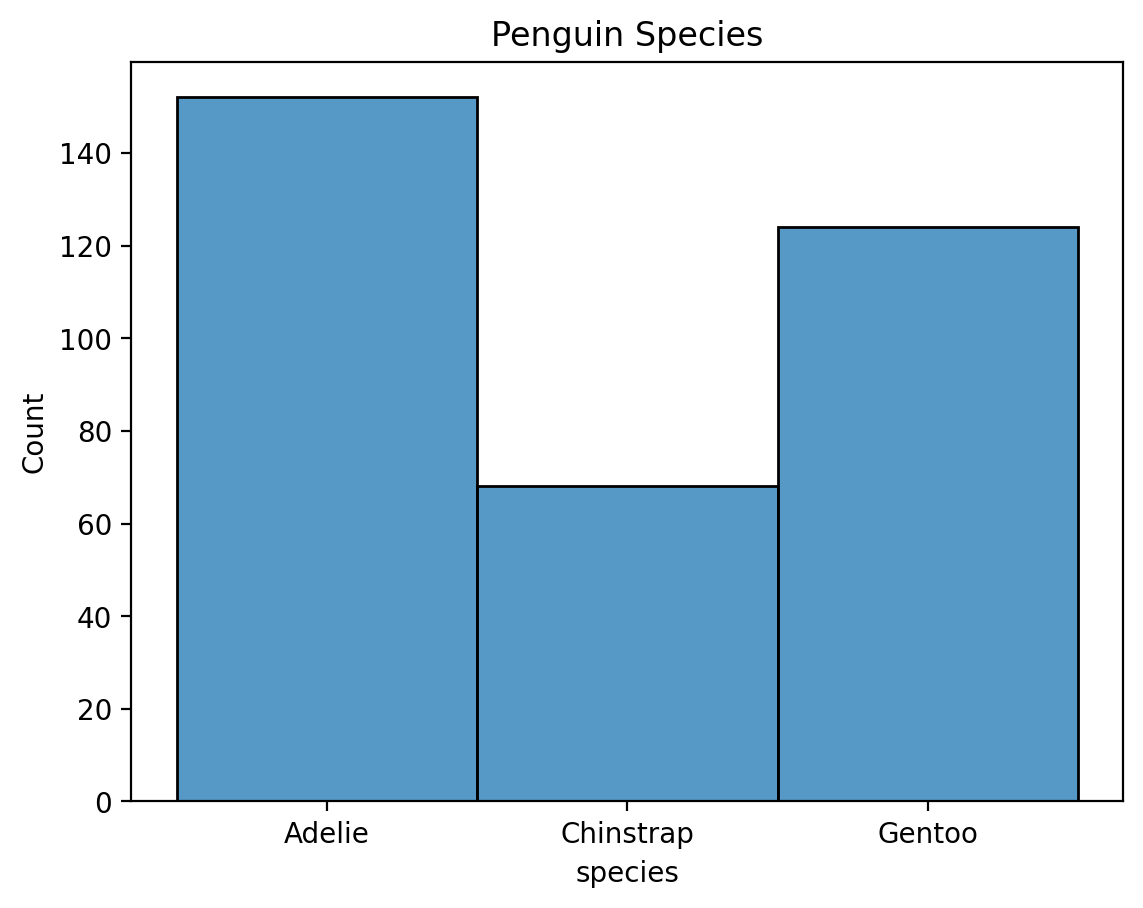

In [9]:
sns.histplot(penguins['species'])
plt.title('Penguin Species')
plt.show()

In [10]:
avg_body_mass = penguins.groupby("species")["body_mass_g"].mean().sort_values(ascending=False)

In [11]:
print("Average Body Mass by Penguin Species (grams):")
print(avg_body_mass)

Average Body Mass by Penguin Species (grams):
species
Gentoo       5076.016260
Chinstrap    3733.088235
Adelie       3700.662252
Name: body_mass_g, dtype: float64


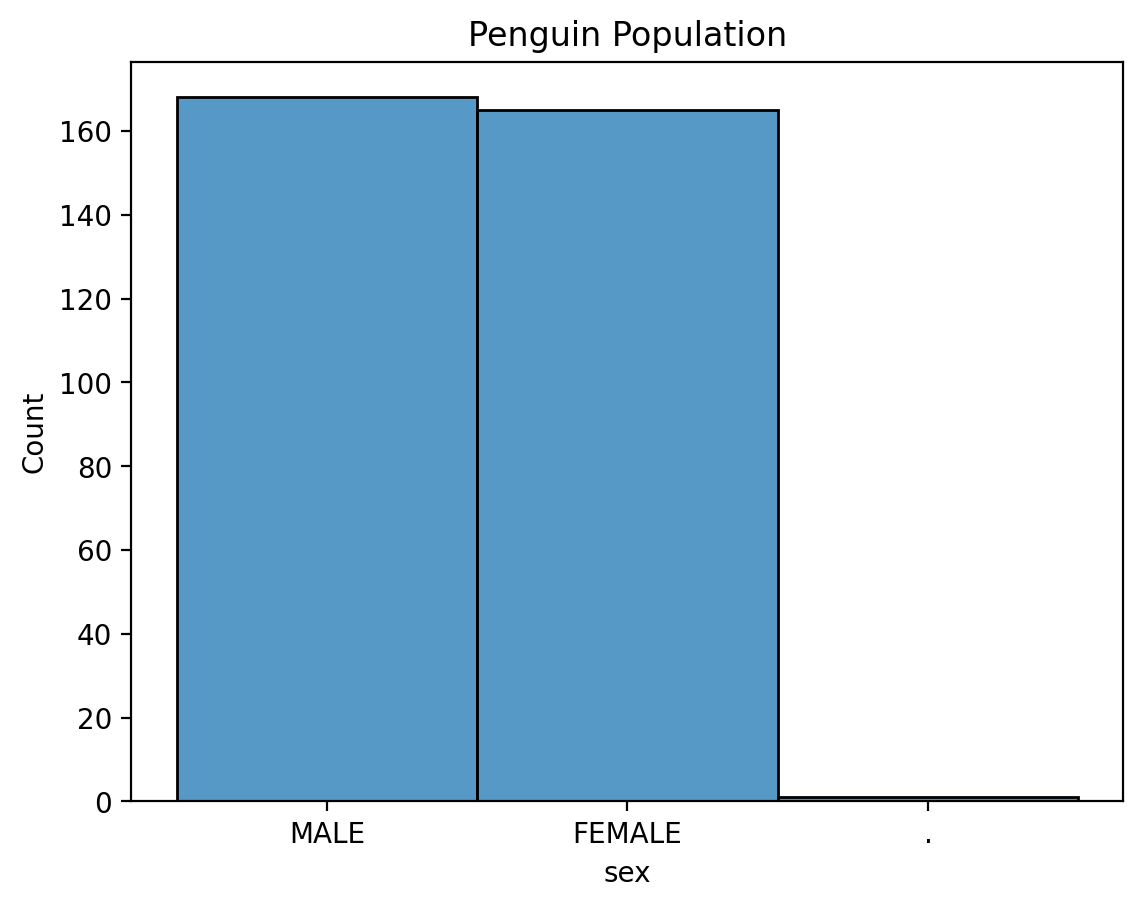

In [12]:
sns.histplot(penguins['sex'])
plt.title('Penguin Population')
plt.show()

In [13]:
total_population = penguins["species"].count()

In [14]:
total_population

344

In [36]:
culmen_per_species = penguins.loc[penguins.groupby("species")["culmen_length_mm"].idxmax()]

In [38]:
display(culmen_per_species)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
19,Adelie,Torgersen,46.0,21.5,194.0,4200.0,MALE
169,Chinstrap,Dream,58.0,17.8,181.0,3700.0,FEMALE
253,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,MALE


In [40]:
penguins = penguins.dropna(subset=["sex"])

In [42]:
male_counts = penguins[penguins["sex"] == "MALE"]["species"].value_counts()

In [44]:
display(male_counts)

species
Adelie       73
Gentoo       61
Chinstrap    34
Name: count, dtype: int64

In [46]:
penguins = penguins.dropna(subset=["sex"])

In [48]:
female_counts = penguins[penguins["sex"] == "FEMALE"]["species"].value_counts()

In [50]:
display(female_counts)

species
Adelie       73
Gentoo       58
Chinstrap    34
Name: count, dtype: int64